# Human-Mammalian Brain - Subcortex 10X snRNASeq analysis: clustering and annotations

You need to be connected to the internet to run this notebook or connected to a cache that has the HMBA data downloaded already.

The notebook presented here shows quick visualizations from precomputed metadata in the atlas. For examples on accessing the expression matrices, specifically selecting genes from expression matrices, see the  [``general_accessing_10x_snRNASeq_tutorial.ipynb``](https://alleninstitute.github.io/abc_atlas_access/notebooks/general_accessing_10x_snRNASeq_tutorial.html) tutorial/example. In a related tutorial, we also show how to access and use [HMBA Subcortex gene expression data](https://alleninstitute.github.io/abc_atlas_access/notebooks/hmba_subcortex_10X_snRNASeq_tutorial.html).

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional

from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

We will interact with the data using the **AbcProjectCache**. This cache object downloads data requested by the user, tracks which files have already been downloaded to your local system, and serves the path to the requested data on disk. For metadata, the cache can also directly serve up a Pandas DataFrame. See the [``getting_started``](https://alleninstitute.github.io/abc_atlas_access/notebooks/getting_started.html) notebook for more details on using the cache including installing it if it has not already been.

**Change the download_base variable to where you would like to download the data in your system.**

In [2]:
download_base = Path('../../data/abc_atlas')
abc_cache = AbcProjectCache.from_cache_dir(
    cache_dir=download_base,
    s3_bucket='allen-brain-cell-atlas-staging',
    auth_required=True
)

abc_cache.current_manifest

'releases/20261031/manifest.json'

## Data overview

We'll quickly walk through the data we will be using in this notebook. The HMBA-Subcortex 10X datasets are located across several directories listed in the `ABCProjectCache`. Below are the directories where the subcortex data can be found:
- HMBA-10xMultiome-Subcortex
- HMBA-Subcortex-taxonomy

Below we list the data and metadata in the HMBA-10xMultiome-Subcortex dataset.

In [3]:
print("HMBA-10xMultiome-Subcortex: gene expression data (h5ad)\n\t", abc_cache.list_expression_matrix_files(directory='HMBA-10xMultiome-Subcortex'))
print("HMBA-10xMultiome-Subcortex: metadata (csv)\n\t", abc_cache.list_metadata_files(directory='HMBA-10xMultiome-Subcortex'))

HMBA-10xMultiome-Subcortex: gene expression data (h5ad)
	 ['HMBA-10xMultiome-Subcortex/log2', 'HMBA-10xMultiome-Subcortex/raw']
HMBA-10xMultiome-Subcortex: metadata (csv)
	 ['barcoded_cell_sample', 'cell_metadata', 'donor', 'value_sets']


We will also use metadata from the HMBA-Subcortex taxonomy directory. Below is the list of available files:

In [4]:
print("HMBA-Subcortex-taxonomy: metadata (csv)\n\t", abc_cache.list_metadata_files(directory='HMBA-Subcortex-taxonomy'))

HMBA-Subcortex-taxonomy: metadata (csv)
	 ['cell_2d_embedding_coordinates', 'cell_to_cluster_membership', 'cluster', 'cluster_annotation_term', 'cluster_annotation_term_set', 'cluster_to_cluster_annotation_membership', 'cluster_to_dominant_region', 'cluster_to_neurotransmitter']


### Cell metadata

Essential cell metadata is stored as a CSV file that we load as a Pandas DataFrame. Each row represents one cell indexed by a *cell label*. The *cell label* is the concatenation of barcode and name of the sample. In this context, the sample is the *barcoded cell sample* that represents a single load into one port of the 10x Chromium. Note that cell barcodes are only unique within a single *barcoded cell sample* and that the same barcode can be reused.

Each cell is associated with a *library label*, *donor label*, *alignment_job_id*, *feature_matrix_label* and *dataset_label* identifying which data package this cell is part of. This metadata file will be combined with other metadata files that ship with this package to add information associated with the donor, UMAP coordinates, cluster assignments, and more.

Below, we load the first of the metadata used in this tutorial. This represents the cell metadata for the aligned dataset.

The command we use below both downloads the data if it is not already available in the local cache and loads the data as a Pandas DataFrame. This pattern of loading metadata is repeated throughout the tutorials.

In [5]:
cell = abc_cache.get_metadata_dataframe(
    directory='HMBA-10xMultiome-Subcortex',
    file_name='cell_metadata',
    dtype={'cell_label': str}
).set_index('cell_label')
print("Number of cells = ", len(cell))
cell.head()

cell_metadata.csv: 100%|██████████| 92.4M/92.4M [00:03<00:00, 25.6MMB/s]  


Number of cells =  678917


,barcoded_cell_sample_label,nCount_RNA,nFeature_RNA,doublet_score,donor_label,alignment_job_id,In_BG_taxonomy_dataset,feature_matrix_label,dataset_label
cell_label,,,,,,,,,
GTTCCTGGTTAGCATG-P0005_1,P0005_1,33732,6363,0.118006,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex
TACTGAGGTTAGGATT-P0005_1,P0005_1,29309,6123,0.520672,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex
TCTTCAAGTTTATGGG-P0005_1,P0005_1,28284,5758,0.125381,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex
CCCTCAGTCAGCACCA-P0005_1,P0005_1,25495,5729,0.225403,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex
AACTACTCACCTACTT-P0005_1,P0005_1,23770,5132,0.557602,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex


We can use pandas `groupby` function to see how many unique items are associated for each field and list them out if the number of unique items is small.

In [6]:
def print_column_info(df):
    
    for c in df.columns:
        grouped = df[[c]].groupby(c).count()
        members = ''
        if len(grouped) < 30:
            members = str(list(grouped.index))
        print("Number of unique %s = %d %s" % (c, len(grouped), members))

In [7]:
print_column_info(cell)

Number of unique barcoded_cell_sample_label = 146 
Number of unique nCount_RNA = 59999 
Number of unique nFeature_RNA = 9231 
Number of unique doublet_score = 639280 
Number of unique donor_label = 4 ['CJ23.56.002', 'CJ23.56.003', 'CJ24.56.001', 'CJ24.56.004']
Number of unique alignment_job_id = 9 [231224, 240110, 240307, 240323, 240807, 240822, 241212, 250114, 250529]
Number of unique In_BG_taxonomy_dataset = 2 [0, 1]
Number of unique feature_matrix_label = 1 ['HMBA-10xMultiome-Subcortex']
Number of unique dataset_label = 1 ['HMBA-10xMultiome-Subcortex']


### Donor and Barcoded Cell Sample metadata

The first two associated metadata we load are the `donor` and `barcoded_cell_sample` tables. The donor table contains species, sex, and age information. The `barcoded_cell_sample table` contains  on 10X methods, the tissue was extracted from, and the aliquots that went in processing.

In [8]:
donor = abc_cache.get_metadata_dataframe(
    directory='HMBA-10xMultiome-Subcortex',
    file_name='donor'
).set_index('donor_label')
donor.head()

donor.csv: 100%|██████████| 525/525 [00:00<00:00, 4.32kMB/s]


,donor_species,species_scientific_name,species_genus,donor_sex,donor_age,donor_age_value,donor_age_unit,donor_nhash_id
donor_label,,,,,,,,
CJ23.56.002,NCBITaxon:9483,Callithrix jacchus,Marmoset,Male,6.6 yrs,6.555925,years,DO-RLGX3443
CJ23.56.003,NCBITaxon:9483,Callithrix jacchus,Marmoset,Male,2.0 yrs,1.958904,years,DO-KKLW5964
CJ24.56.001,NCBITaxon:9483,Callithrix jacchus,Marmoset,Female,5.4 yrs,5.391781,years,DO-PWVO1989
CJ24.56.004,NCBITaxon:9483,Callithrix jacchus,Marmoset,Female,4.0 yrs,3.956284,years,DO-NOUP1048


In [ ]:
barcoded_cell_sample = abc_cache.get_metadata_dataframe(
    directory='HMBA-10xMultiome-Subcortex',
    file_name='barcoded_cell_sample'
).set_index('barcoded_cell_sample_label')
barcoded_cell_sample.head()

barcoded_cell_sample.csv: 100%|██████████| 30.2k/30.2k [00:00<00:00, 214kMB/s] 


,tissue_name,dissociated_cell_sample_name,donor_label,hemisphere,RNA_aliquot_nhash_id,ATAC_aliquot_nhash_id,cell_specimen_type,ATAC_library_technique,RNA_library_technique,parcellation_term_identifier,region_of_interest_name,region_of_interest_label,anatomical_division_label,enrichment_population
barcoded_cell_sample_label,,,,,,,,,,,,,,
P0005_1,CJ23.56.002.CX.45.MD,231002_CJ23.56.002.CX.45.MD.Multiome,CJ23.56.002,rh,LP-JUVUVW380563,LP-NILLNM644050,Nuclei,10xMultiome;ATAC,10xMultiome;GEX,DHBA:10155,brain,Br,Brain,"70% NeuN+, 10% OLIG2-, 20% OLIG2+"
P0005_2,CJ23.56.002.CX.45.MD,231002_CJ23.56.002.CX.45.MD.Multiome,CJ23.56.002,rh,LP-JUVUVW380563,LP-NILLNM644050,Nuclei,10xMultiome;ATAC,10xMultiome;GEX,DHBA:10155,brain,Br,Brain,No FACS
P0008_1,CJ23.56.002.CX.44.CaHdl,231019_CJ23.56.002.CX.44.CaHdl.Multiome,CJ23.56.002,rh,LP-ABBZBI859245,LP-BRRSAW519135,Nuclei,10xMultiome;ATAC,10xMultiome;GEX,DHBA:10155,brain,Br,Brain,No FACS
P0008_2,CJ23.56.002.CX.44.CaHdl,231019_CJ23.56.002.CX.44.CaHdl.Multiome,CJ23.56.002,rh,LP-ABBZBI859245,LP-BRRSAW519135,Nuclei,10xMultiome;ATAC,10xMultiome;GEX,DHBA:10155,brain,Br,Brain,No FACS
P0009_1,CJ23.56.002.CX.44.HIP-AMY,231020_CJ23.56.002.CX.44.HIP-AMY.Multiome,CJ23.56.002,rh,LP-ABBZBI859245,LP-BRRSAW519135,Nuclei,10xMultiome;ATAC,10xMultiome;GEX,DHBA:10155,brain,Br,Brain,No FACS


We combine these into an extended cell metadata table.

In [ ]:
cell_extended = cell.join(donor, on='donor_label')
cell_extended = cell_extended.join(barcoded_cell_sample, on='barcoded_cell_sample_label', rsuffix='_barcoded_cell_sample_table')

del cell

Below we use a pandas `groupby` to show the number of cells from each marmoset donor.

In [51]:
cell_extended.groupby('donor_label')[['donor_label']].count()

,donor_label
donor_label,
CJ23.56.002,32330
CJ23.56.003,329353
CJ24.56.001,221105
CJ24.56.004,96129


We can also use the `groupby` function to show the number of cells in each tissue the cells are extracted from.

In [12]:
cell_extended.groupby('dissociated_cell_sample_name')[['dissociated_cell_sample_name']].count()

,dissociated_cell_sample_name
dissociated_cell_sample_name,
231002_CJ23.56.002.CX.45.MD.Multiome,3537
231019_CJ23.56.002.CX.44.CaHdl.Multiome,8654
231020_CJ23.56.002.CX.44.HIP-AMY.Multiome,9229
231023_CJ23.56.002.CX.44.CaHvm-Cla.Multiome,10910
231027_CJ23.56.003.CX.03.LH.Multiome,11051
...,...
241112_CJ24.56.004.CX.06.04.Multiome,6397
241112_CJ24.56.004.CX.06.05.Multiome,11470
241118_CJ24.56.004.CX.06.06.Multiome,9000


### Adding color and feature order

Each major feature in the donor and library table is associated with unique colors and an ordering with the set of values. Below we load the `value_sets` DataFrame which is a mapping from the various value in the donor and species tables to those colors and orderings. We incorporate these values into the cell metadata table. 

In [13]:
value_sets = abc_cache.get_metadata_dataframe(
    directory='HMBA-10xMultiome-Subcortex',
    file_name='value_sets'
).set_index('label')
value_sets.head()

value_sets.csv: 100%|██████████| 4.16k/4.16k [00:00<00:00, 32.0kMB/s]


,table,field,description,order,external_identifier,parent_label,color_hex_triplet
label,,,,,,,
Female,donor,donor_sex,Female,1,NaN,NaN,#565353
Male,donor,donor_sex,Male,2,NaN,NaN,#ADC4C3
Human,donor,species_genus,Human,1,NCBITaxon:9605,NaN,#377eb8
Macaque,donor,species_genus,Macaque,2,NCBITaxon:9539,NaN,#4daf4a
Marmoset,donor,species_genus,Marmoset,3,NCBITaxon:9481,NaN,#FF5F5D


We define a convince function to add colors for the various values in the data (e.g. unique region of interest or donor sex values).

In [14]:
def extract_value_set(cell_metadata_df: pd.DataFrame, input_value_set: pd.DataFrame, input_value_set_label: str):
    """Add color and order columns to the cell metadata dataframe based on the input
    value set.

    Columns are added as {input_value_set_label}_color and {input_value_set_label}_order.

    Parameters
    ----------
    cell_metadata_df : pd.DataFrame
        DataFrame containing cell metadata.
    input_value_set : pd.DataFrame
        DataFrame containing the value set information.
    input_value_set_label : str
        The the column name to extract color and order information for. will be added to the cell metadata.
    """
    cell_metadata_df[f'{input_value_set_label}_color'] = input_value_set[
        input_value_set['field'] == input_value_set_label
    ].loc[cell_metadata_df[input_value_set_label]]['color_hex_triplet'].values
    cell_metadata_df[f'{input_value_set_label}_order'] = input_value_set[
        input_value_set['field'] == input_value_set_label
    ].loc[cell_metadata_df[input_value_set_label]]['order'].values

Use our function to add the relevant color and order columns to our cell_metadata table.

In [15]:
# Add region of interest color and order
extract_value_set(cell_extended, value_sets, 'region_of_interest_label')
# Add species common name color and order
extract_value_set(cell_extended, value_sets, 'species_genus')
# Add species scientific name color and order
extract_value_set(cell_extended, value_sets, 'species_scientific_name')
# Add donor sex color and order
extract_value_set(cell_extended, value_sets, 'donor_sex')
cell_extended.head()

,barcoded_cell_sample_label,nCount_RNA,nFeature_RNA,doublet_score,donor_label,alignment_job_id,In_BG_taxonomy_dataset,feature_matrix_label,dataset_label,donor_species,...,anatomical_division_label,enrichment_population,region_of_interest_label_color,region_of_interest_label_order,species_genus_color,species_genus_order,species_scientific_name_color,species_scientific_name_order,donor_sex_color,donor_sex_order
cell_label,,,,,,,,,,,,,,,,,,,,,
GTTCCTGGTTAGCATG-P0005_1,P0005_1,33732,6363,0.118006,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,NCBITaxon:9483,...,Brain,"70% NeuN+, 10% OLIG2-, 20% OLIG2+",#E0E0E0,1,#FF5F5D,3,#FF5F5D,4,#ADC4C3,2
TACTGAGGTTAGGATT-P0005_1,P0005_1,29309,6123,0.520672,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,NCBITaxon:9483,...,Brain,"70% NeuN+, 10% OLIG2-, 20% OLIG2+",#E0E0E0,1,#FF5F5D,3,#FF5F5D,4,#ADC4C3,2
TCTTCAAGTTTATGGG-P0005_1,P0005_1,28284,5758,0.125381,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,NCBITaxon:9483,...,Brain,"70% NeuN+, 10% OLIG2-, 20% OLIG2+",#E0E0E0,1,#FF5F5D,3,#FF5F5D,4,#ADC4C3,2
CCCTCAGTCAGCACCA-P0005_1,P0005_1,25495,5729,0.225403,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,NCBITaxon:9483,...,Brain,"70% NeuN+, 10% OLIG2-, 20% OLIG2+",#E0E0E0,1,#FF5F5D,3,#FF5F5D,4,#ADC4C3,2
AACTACTCACCTACTT-P0005_1,P0005_1,23770,5132,0.557602,CJ23.56.002,240822,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,NCBITaxon:9483,...,Brain,"70% NeuN+, 10% OLIG2-, 20% OLIG2+",#E0E0E0,1,#FF5F5D,3,#FF5F5D,4,#ADC4C3,2


### UMAP spatial embedding

Now that we've merged our donor and library metadata into the main cells data, our next step is to plot these values in the Uniform Manifold Approximation and Projection (UMAP) for cells in the dataset. The UMAP is a dimension reduction technique that can be used for visualizing and exploring large-dimension datasets. 

Below we load this 2-D embedding for a sub selection of our cells and merge the x-y coordinates into the extended cell metadata we are creating. 

In [16]:
cell_2d_embedding_coordinates = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cell_2d_embedding_coordinates'
).set_index('cell_label')
cell_2d_embedding_coordinates.head()

cell_2d_embedding_coordinates.csv: 100%|██████████| 30.5M/30.5M [00:01<00:00, 26.4MMB/s]


,x,y
cell_label,,
GTTCCTGGTTAGCATG-P0005_1,14.662888,10.134843
TACTGAGGTTAGGATT-P0005_1,-8.280969,18.335058
TCTTCAAGTTTATGGG-P0005_1,7.183354,13.461928
CCCTCAGTCAGCACCA-P0005_1,7.140094,13.440581
AACTACTCACCTACTT-P0005_1,-8.869915,18.777521


In [17]:
cell_extended = cell_extended.join(cell_2d_embedding_coordinates)
cell_extended = cell_extended.sample(frac=1)

del cell_2d_embedding_coordinates

We define a small helper function *plot_umap* to visualize the cells on the UMAP. In the examples below we will plot associated cell information colorized by sex.

In [18]:
def plot_umap(
    xx: np.ndarray,
    yy: np.ndarray,
    cc: np.ndarray = None,
    val: np.ndarray = None,
    fig_width: float = 8,
    fig_height: float = 8,
    cmap: Optional[plt.Colormap] = None,
    labels: np.ndarray = None,
    term_orders: np.ndarray = None,
    colorbar: bool = False,
    sizes: np.ndarray = None
 ) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot a scatter plot of the UMAP coordinates.

    Parameters
    ----------
    xx : array-like
        x-coordinates of the points to plot.
    yy : array-like
        y-coordinates of the points to plot.
    cc : array-like, optional
        colors of the points to plot. If None, the points will be colored by the values in `val`.
    val : array-like, optional
        values of the points to plot. If None, the points will be colored by the values in `cc`.
    fig_width : float, optional
        width of the figure in inches. Default is 8.
    fig_height : float, optional
        height of the figure in inches. Default is 8.
    cmap : str, optional
        colormap to use for coloring the points. If None, the points will be colored by the values in `cc`.
    labels : array-like, optional
        labels for the points to plot. If None, no labels will be added to the plot.
    term_orders : array-like, optional
        order of the labels for the legend. If None, the labels will be ordered by their appearance in `labels`.
    colorbar : bool, optional
        whether to add a colorbar to the plot. Default is False.
    sizes : array-like, optional
        sizes of the points to plot. If None, all points will have the same size.
    """
    if sizes is None:
        sizes = 1
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    if cmap is not None:
        scatt = ax.scatter(xx, yy, c=val, s=0.5, marker='.', cmap=cmap, alpha=sizes)
    elif cc is not None:
        scatt = ax.scatter(xx, yy, c=cc, s=0.5, marker='.', alpha=sizes)

    if labels is not None:
        from matplotlib.patches import Rectangle
        unique_label_colors = (labels + ',' + cc).unique()
        unique_labels = np.array([label_color.split(',')[0] for label_color in unique_label_colors])
        unique_colors = np.array([label_color.split(',')[1] for label_color in unique_label_colors])

        if term_orders is not None:
            unique_order = term_orders.unique()
            term_order = np.argsort(unique_order)
            unique_labels = unique_labels[term_order]
            unique_colors = unique_colors[term_order]
            
        rects = []
        for color in unique_colors:
            rects.append(Rectangle((0, 0), 1, 1, fc=color))

        legend = ax.legend(rects, unique_labels, loc=1)
        # ax.add_artist(legend)

    if colorbar:
        fig.colorbar(scatt, ax=ax)
    
    return fig, ax

Plot the various donor and library metadata available.

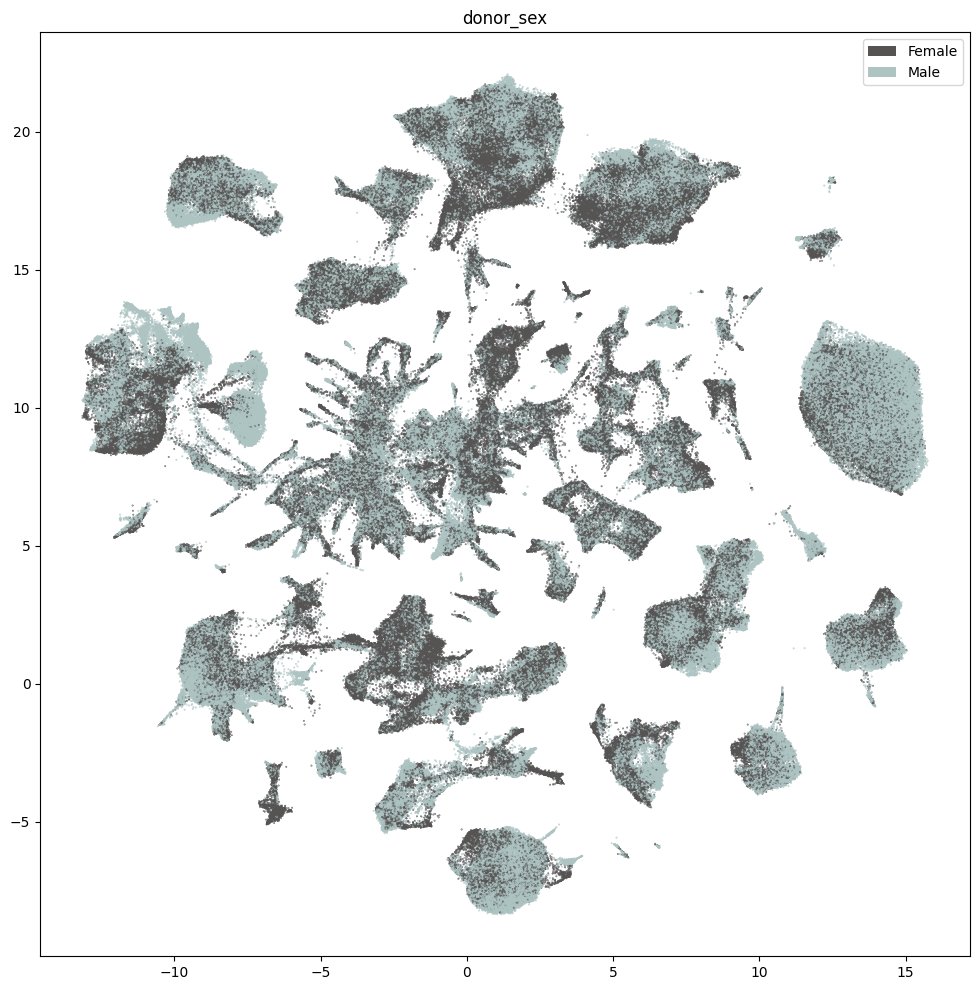

In [21]:
fig, ax = plot_umap(
    cell_extended['x'],
    cell_extended['y'],
    cc=cell_extended['donor_sex_color'],
    labels=cell_extended['donor_sex'],
    term_orders=cell_extended['donor_sex_order'],
    fig_width=12,
    fig_height=12
)
res = ax.set_title("donor_sex")
plt.show()

Below we show the region of interest for the Subcortex data. However, that Marmoset does not have fine grained ROIs available and is marked as `Br - Brain`. Later in this tutorial, we'll show the derived regions from the taxonomy.

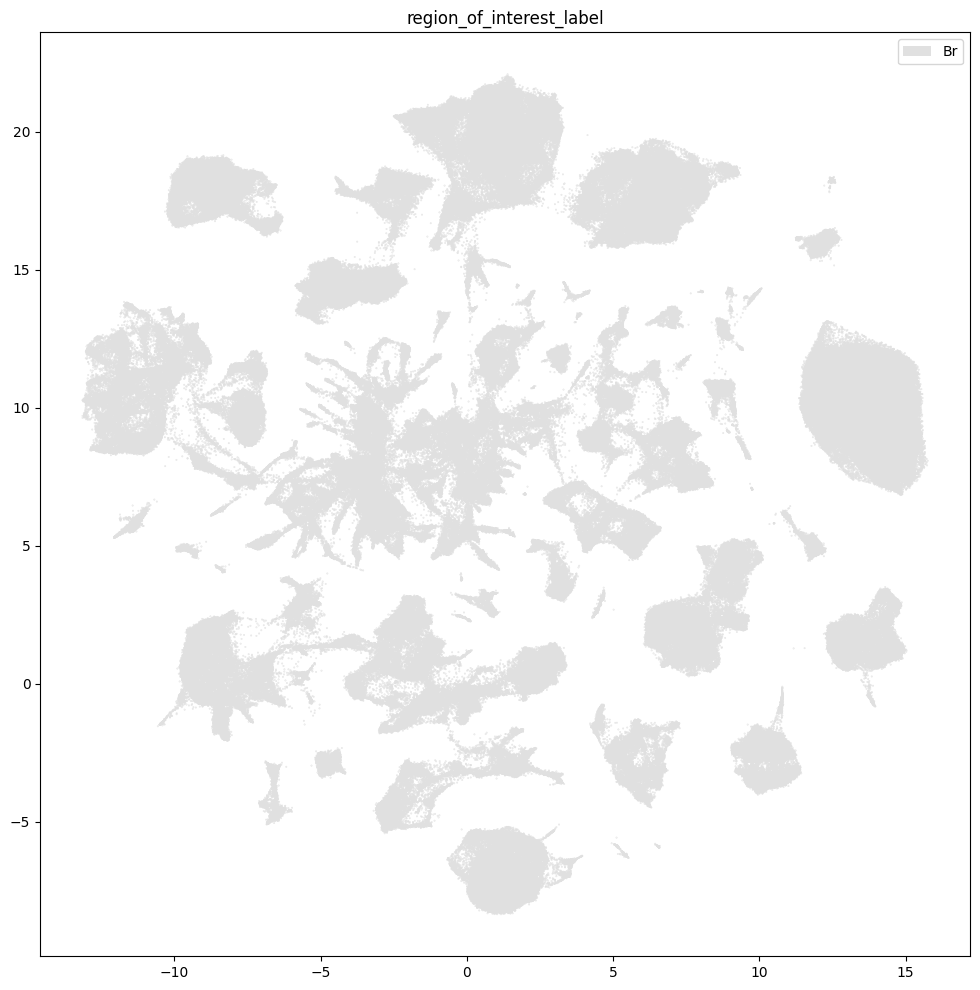

In [22]:
fig, ax = plot_umap(
    cell_extended['x'],
    cell_extended['y'],
    cc=cell_extended['region_of_interest_label_color'],
    labels=cell_extended['region_of_interest_label'],
    term_orders=cell_extended['region_of_interest_label_order'],
    fig_width=12,
    fig_height=12
)
res = ax.set_title("region_of_interest_label")
plt.show()

## Taxonomy Information

The final set of metadata we load into our extended cell metadata file maps the cells into their assigned cluster in the taxonomy. We additionally load metadata for the clusters and compute useful information, such as the number of cells in each taxon at each level of the taxonomy.

First, we load information associated with each Cluster in the taxonomy. This includes a useful alias value for each cluster as well as the number of cells in each cluster.

In [23]:
cluster = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cluster',
    dtype={'number_of_cells': 'Int64'},
).rename(columns={'label': 'cluster_annotation_term_label'}).set_index('cluster_annotation_term_label')
cluster.head()

cluster.csv: 100%|██████████| 64.6k/64.6k [00:00<00:00, 700kMB/s]


,cluster_alias,number_of_cells
cluster_annotation_term_label,,
CS20260831_LVL2_0000,cluster_249,268
CS20260831_LVL2_0001,cluster_254,2004
CS20260831_LVL2_0002,cluster_255,3350
CS20260831_LVL2_0003,cluster_256,143
CS20260831_LVL2_0004,cluster_257,128


Next, we load the table that describes the levels in the taxonomy from Class at the highest to Cluster at the lowest level.

In [24]:
cluster_annotation_term_set = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cluster_annotation_term_set',
).rename(columns={'label': 'cluster_annotation_term_label'})
cluster_annotation_term_set

cluster_annotation_term_set.csv: 100%|██████████| 183/183 [00:00<00:00, 2.10kMB/s]


,name,cluster_annotation_term_label,description,order,parent_term_set_label
0,Class,CCN20260831_LVL0,Class,0,NaN
1,Group,CCN20260831_LVL1,Group,1,CCN20260831_LVL0
2,Cluster,CCN20260831_LVL2,Cluster,2,CCN20260831_LVL1


For the clusters, we load information on the annotations for each cluster. This also includes the term order and color information which we will use to plot later.

In [25]:
cluster_annotation_term = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cluster_annotation_term',
    force_download=True,
    skip_hash_check=True
).rename(columns={'label': 'cluster_annotation_term_label'}).set_index('cluster_annotation_term_label')
cluster_annotation_term.head()

cluster_annotation_term.csv: 100%|██████████| 260k/260k [00:00<00:00, 2.57MMB/s]


,name,cluster_annotation_term_set_label,cluster_annotation_term_set_name,color_hex_triplet,term_order,term_order.1,term_set_order,parent_term_label,parent_term_name,parent_term_set_label,external_label
cluster_annotation_term_label,,,,,,,,,,,
CS20260831_LVL0_00,BG,CCN20260831_LVL0,Class,#CBC3E3,1,1,0,NaN,NaN,NaN,NaN
CS20260831_LVL0_01,CNU-HTH GABA,CCN20260831_LVL0,Class,#E69F00,2,2,0,NaN,NaN,NaN,NaN
CS20260831_LVL0_02,CNU-HTH Glut,CCN20260831_LVL0,Class,#56B4E9,3,3,0,NaN,NaN,NaN,NaN
CS20260831_LVL0_03,CTX-CGE GABA,CCN20260831_LVL0,Class,#839fa3,4,4,0,NaN,NaN,NaN,NaN
CS20260831_LVL0_04,CTX-MGE GABA,CCN20260831_LVL0,Class,#ce4c27,5,5,0,NaN,NaN,NaN,NaN


Finally, we load the cluster to cluster annotation membership table. Each row in this table is a mapping between the clusters and every level of the taxonomy it belongs to, including itself. We'll use this table in a `groupby`s to allow us to count up the number of clusters at each taxonomy level and sum the number of cells in each taxon in the taxonomy a all levels.

In [26]:
cluster_to_cluster_annotation_membership = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cluster_to_cluster_annotation_membership',
).set_index('cluster_annotation_term_label')
membership_with_cluster_info = cluster_to_cluster_annotation_membership.join(
    cluster.reset_index().set_index('cluster_alias')[['number_of_cells']],
    on='cluster_alias'
)
membership_with_cluster_info = membership_with_cluster_info.join(cluster_annotation_term, rsuffix='_anno_term').reset_index()
membership_groupby = membership_with_cluster_info.groupby(
    ['cluster_alias', 'cluster_annotation_term_set_name']
)
membership_with_cluster_info.head()

cluster_to_cluster_annotation_membership.csv: 100%|██████████| 358k/358k [00:00<00:00, 2.04MMB/s]


,cluster_annotation_term_label,cluster_annotation_term_set_name,cluster_annotation_term_name,cluster_alias,cluster_annotation_term_set_label,number_of_cells,name,cluster_annotation_term_set_label_anno_term,cluster_annotation_term_set_name_anno_term,color_hex_triplet,term_order,term_order.1,term_set_order,parent_term_label,parent_term_name,parent_term_set_label,external_label
0,CS20260831_LVL0_00,Class,BG,cluster_249,CCN20260831_LVL0,268,BG,CCN20260831_LVL0,Class,#CBC3E3,1,1,0,NaN,NaN,NaN,NaN
1,CS20260831_LVL0_00,Class,BG,cluster_254,CCN20260831_LVL0,2004,BG,CCN20260831_LVL0,Class,#CBC3E3,1,1,0,NaN,NaN,NaN,NaN
2,CS20260831_LVL0_00,Class,BG,cluster_255,CCN20260831_LVL0,3350,BG,CCN20260831_LVL0,Class,#CBC3E3,1,1,0,NaN,NaN,NaN,NaN
3,CS20260831_LVL0_00,Class,BG,cluster_256,CCN20260831_LVL0,143,BG,CCN20260831_LVL0,Class,#CBC3E3,1,1,0,NaN,NaN,NaN,NaN
4,CS20260831_LVL0_00,Class,BG,cluster_257,CCN20260831_LVL0,128,BG,CCN20260831_LVL0,Class,#CBC3E3,1,1,0,NaN,NaN,NaN,NaN


From the membership table, we create three tables via a `groupby`. First the name of each cluster and its parents.

In [27]:
# term_sets = abc_cache.get_metadata_dataframe(directory='WHB-taxonomy', file_name='cluster_annotation_term_set').set_index('label')
cluster_details = membership_groupby['cluster_annotation_term_name'].first().unstack()
cluster_details = cluster_details[cluster_annotation_term_set['name']] # order columns
cluster_details.sort_values(['Class', 'Group', 'Cluster'], inplace=True)
cluster_details.head()

cluster_annotation_term_set_name,Class,Group,Cluster
cluster_alias,,,
cluster_249,BG,AMY-STR ITC-NUDAP eSPN,cluster_249
cluster_254,BG,AMY-STR ITC-NUDAP eSPN,cluster_254
cluster_255,BG,AMY-STR ITC-NUDAP eSPN,cluster_255
cluster_256,BG,AMY-STR ITC-NUDAP eSPN,cluster_256
cluster_257,BG,AMY-STR ITC-NUDAP eSPN,cluster_257


Next the plotting order of each of the clusters and their parents.

In [28]:
cluster_order = membership_groupby['term_order'].first().unstack()
cluster_order.sort_values(['Class', 'Group', 'Cluster'], inplace=True)
cluster_order.rename(
    columns={'Class': 'Class_order',
             'Group': 'Group_order',
             'Cluster': 'Cluster_order'},
    inplace=True
)
cluster_order.head()

cluster_annotation_term_set_name,Class_order,Cluster_order,Group_order
cluster_alias,,,
cluster_249,1,1,1
cluster_254,1,2,1
cluster_255,1,3,1
cluster_256,1,4,1
cluster_257,1,5,1


Finally, the colors we will use to plot for each of the unique taxons at all levels.

In [29]:
cluster_colors = membership_groupby['color_hex_triplet'].first().unstack()
cluster_colors = cluster_colors[cluster_annotation_term_set['name']]
cluster_colors.sort_values(['Class', 'Group', 'Cluster'], inplace=True)
cluster_colors.head()

cluster_annotation_term_set_name,Class,Group,Cluster
cluster_alias,,,
cluster_1730,#0072B2,#047b9f,#016fa3
cluster_331,#0072B2,#447E6C,#3b8373
cluster_330,#0072B2,#447E6C,#408d6e
cluster_326,#0072B2,#447E6C,#417b78
cluster_329,#0072B2,#447E6C,#4e786a


Next, we bring it all together by loading the mapping of cells to cluster and join into our final metadata table.

In [30]:
cell_to_cluster_membership = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cell_to_cluster_membership',
).set_index('cell_label')
cell_to_cluster_membership.head()

cell_to_cluster_membership.csv: 100%|██████████| 39.4M/39.4M [00:01<00:00, 20.4MMB/s]  


,cluster_alias,label
cell_label,,
GTTCCTGGTTAGCATG-P0005_1,cluster_1,CS20260831_LVL2_1088
TACTGAGGTTAGGATT-P0005_1,cluster_17,CS20260831_LVL2_1536
TCTTCAAGTTTATGGG-P0005_1,cluster_42,CS20260831_LVL2_1524
CCCTCAGTCAGCACCA-P0005_1,cluster_41,CS20260831_LVL2_1523
AACTACTCACCTACTT-P0005_1,cluster_18,CS20260831_LVL2_1537


We merge this table with information from our clusters.

In [32]:
cell_extended = cell_extended.join(cell_to_cluster_membership, rsuffix='_cell_to_cluster_membership')
cell_extended = cell_extended.join(cluster_details, on='cluster_alias')
cell_extended = cell_extended.join(cluster_colors, on='cluster_alias', rsuffix='_color')
cell_extended = cell_extended.join(cluster_order, on='cluster_alias')

del cell_to_cluster_membership

cell_extended.head()

,barcoded_cell_sample_label,nCount_RNA,nFeature_RNA,doublet_score,donor_label,alignment_job_id,In_BG_taxonomy_dataset,feature_matrix_label,dataset_label,donor_species,...,label,Class,Group,Cluster,Class_color,Group_color,Cluster_color,Class_order,Cluster_order,Group_order
cell_label,,,,,,,,,,,,,,,,,,,,,
CGTGCTTTCCTAAATG-P0066_3,P0066_3,7502,3517,0.030248,CJ24.56.001,250114,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,NCBITaxon:9483,...,CS20260831_LVL2_0194,BG,STR SST-CHODL GABA,cluster_906,#CBC3E3,#708297,#7d8c91,1,195,27
TCTAGCGAGGGCCACT-P0074_3,P0074_3,12423,4408,0.017334,CJ24.56.004,250114,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,NCBITaxon:9483,...,CS20260831_LVL2_0256,BG,STRd D1 Striosome SPN,cluster_240,#CBC3E3,#d62728,#cc221f,1,257,33
GAGTGATCAACTAGCC-P0071_3,P0071_3,4754,2605,0.227992,CJ24.56.001,250114,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,NCBITaxon:9483,...,CS20260831_LVL2_1397,TEL Glut,L5-6 IT CTX-PArCx Glut,cluster_1055,#88CCEE,#C183D8,#be8ab1,15,1398,178
TTCGCAACATGAGTTT-P0052_2,P0052_2,24905,6311,0.401424,CJ24.56.001,241212,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,NCBITaxon:9483,...,CS20260831_LVL2_0779,MB-HB GABA,MB-HB PAX5 GABA,cluster_1504,#CC79A7,#fd8d3c,#f26f41,9,780,104
TGTGTTAAGAAGCTAG-P0065_2,P0065_2,4652,2621,0.068995,CJ24.56.001,250114,1,HMBA-10xMultiome-Subcortex,HMBA-10xMultiome-Subcortex,NCBITaxon:9483,...,CS20260831_LVL2_1025,Nonneuron,Astro-TE NN,cluster_799,#999999,#6BC9B2,#71c6cc,12,1026,130


In [33]:
print_column_info(cell_extended)

Number of unique barcoded_cell_sample_label = 146 
Number of unique nCount_RNA = 59999 
Number of unique nFeature_RNA = 9231 
Number of unique doublet_score = 639280 
Number of unique donor_label = 4 ['CJ23.56.002', 'CJ23.56.003', 'CJ24.56.001', 'CJ24.56.004']
Number of unique alignment_job_id = 9 [231224, 240110, 240307, 240323, 240807, 240822, 241212, 250114, 250529]
Number of unique In_BG_taxonomy_dataset = 2 [0, 1]
Number of unique feature_matrix_label = 1 ['HMBA-10xMultiome-Subcortex']
Number of unique dataset_label = 1 ['HMBA-10xMultiome-Subcortex']
Number of unique donor_species = 1 ['NCBITaxon:9483']
Number of unique species_scientific_name = 1 ['Callithrix jacchus']
Number of unique species_genus = 1 ['Marmoset']
Number of unique donor_sex = 2 ['Female', 'Male']
Number of unique donor_age = 4 ['2.0 yrs', '4.0 yrs', '5.4 yrs', '6.6 yrs']
Number of unique donor_age_value = 4 [1.95890411, 3.956284153, 5.391780822, 6.555924845]
Number of unique donor_age_unit = 1 ['years']
Number 

#### Plotting the taxonomy

Now that we have our cells with associated taxonomy information, we'll plot them into the UMAP we showed previously.

Below we plot the taxonomy mapping of the cells for each level in the taxonomy.

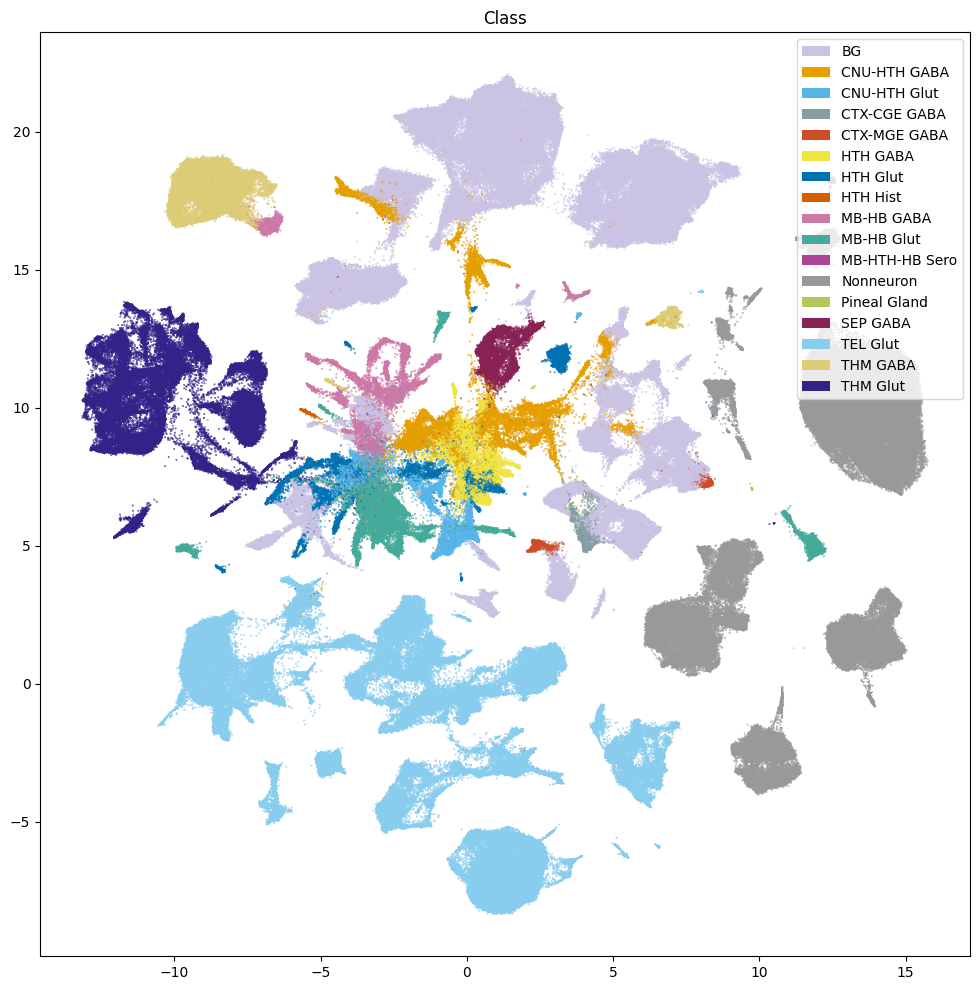

In [34]:
fig, ax = plot_umap(
    cell_extended['x'],
    cell_extended['y'],
    cc=cell_extended['Class_color'],
    labels=cell_extended['Class'],
    term_orders=cell_extended['Class_order'],
    fig_width=12,
    fig_height=12
)
res = ax.set_title("Class")
plt.show()

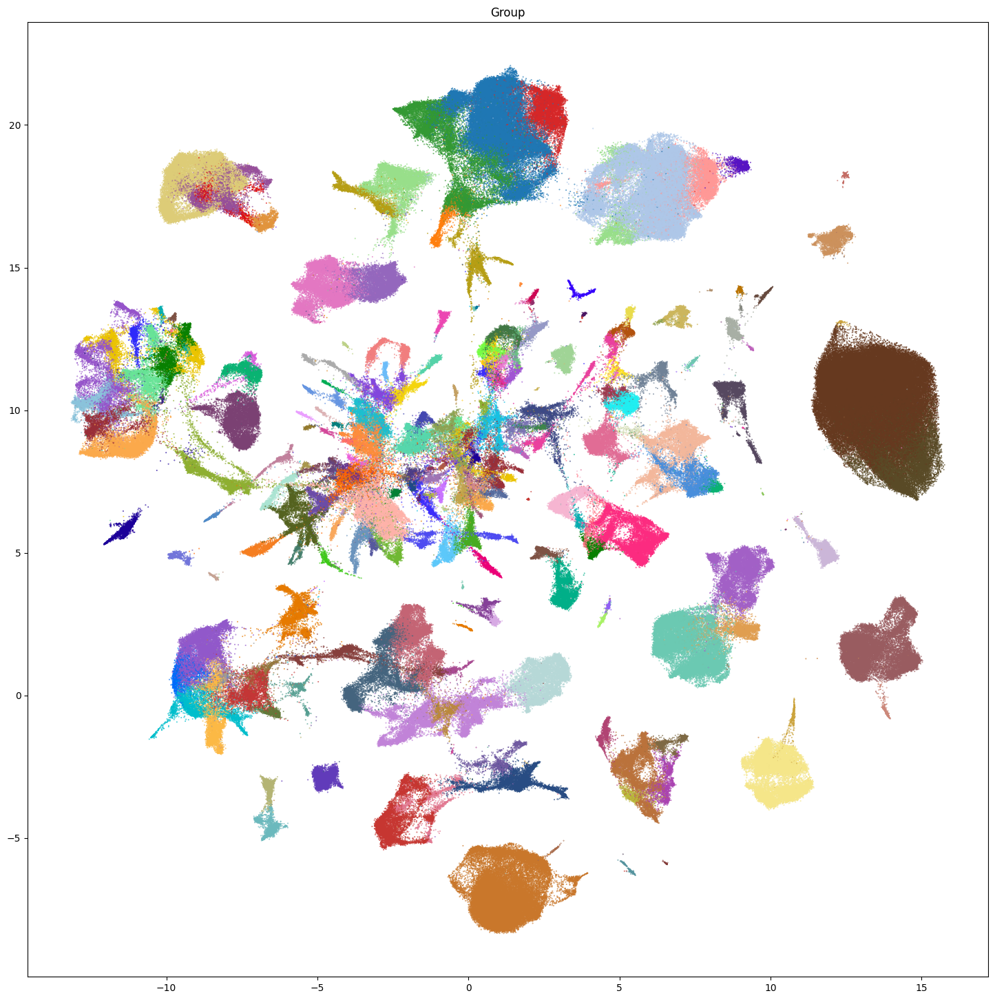

In [ ]:
# We Suppress the group names here due to the large number of Groups. Uncomment the line below to show them.
fig, ax = plot_umap(
    cell_extended['x'],
    cell_extended['y'],
    cc=cell_extended['Group_color'],
    # labels=cell_extended['Group'],
    term_orders=cell_extended['Group_order'],
    fig_width=18,
    fig_height=18
)
res = ax.set_title("Group")
plt.show()

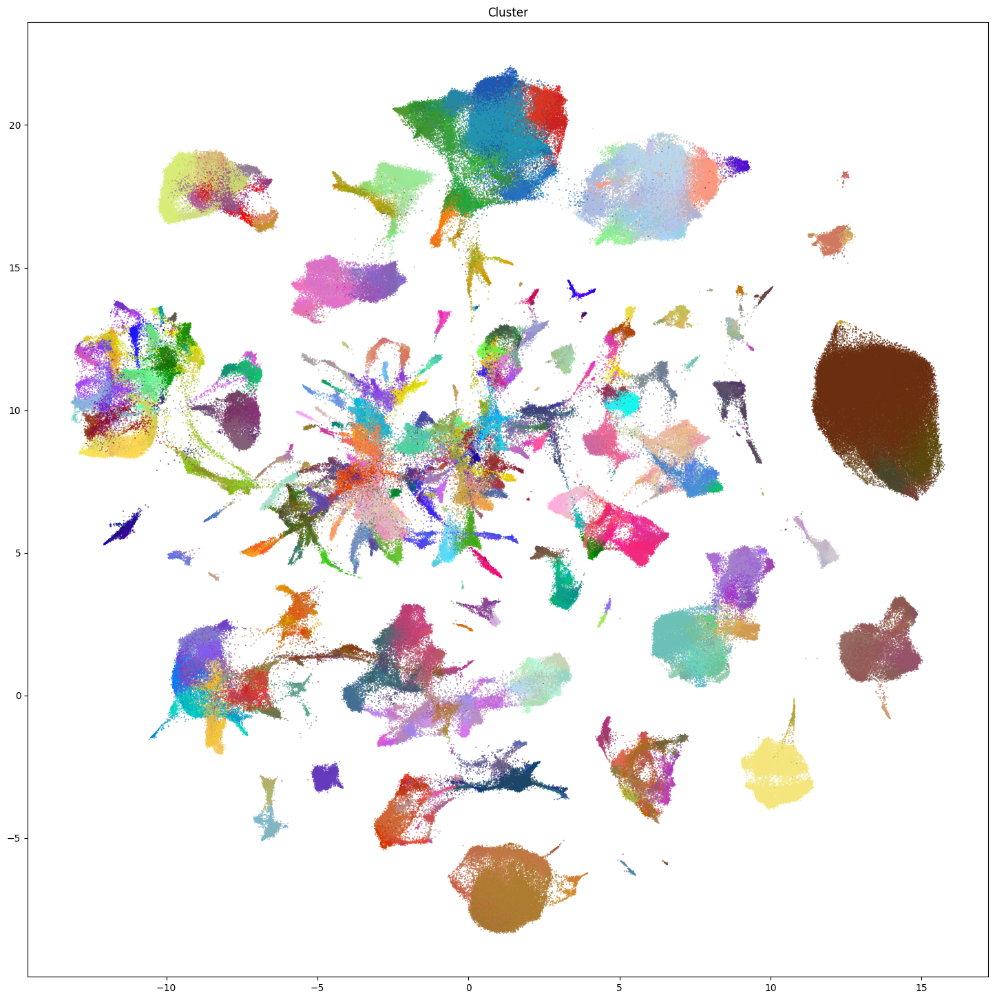

In [36]:
fig, ax = plot_umap(
    cell_extended['x'],
    cell_extended['y'],
    cc=cell_extended['Cluster_color'],
    term_orders=cell_extended['Cluster_order'],
    fig_width=18,
    fig_height=18
)
res = ax.set_title("Cluster")
plt.show()

### Region and Neurotransmitter

Additionally from the taxonomy, for each celltype at the Cluster and Group level, we have inferred region information and neurotransmitter information.

We load both tables below and merge them into our cell_extended table.

In [57]:
cluster_to_dominant_region

,Cluster_Dominant_Region,Cluster_Dominant_Region_color,Group_Dominant_Region,Group_Dominant_Region_color
cluster_alias,,,,
cluster_249,AMY,#cc3333,Multi,#989998
cluster_254,Multi,#989998,Multi,#989998
cluster_255,AMY,#cc3333,Multi,#989998
cluster_256,AMY,#cc3333,Multi,#989998
cluster_257,AMY,#cc3333,Multi,#989998
...,...,...,...,...
cluster_212,THM,#f06597,THM,#f06597
cluster_217,THM,#f06597,THM,#f06597
cluster_223,THM,#f06597,THM,#f06597


In [55]:
cluster_to_dominant_region = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cluster_to_dominant_region',
).set_index('cluster_alias')
cluster_to_neurotransmitter = abc_cache.get_metadata_dataframe(
    directory='HMBA-Subcortex-taxonomy',
    file_name='cluster_to_neurotransmitter',
).set_index('cluster_alias')

cluster_to_neurotransmitter.csv: 100%|██████████| 67.3k/67.3k [00:00<00:00, 430kMB/s] 


In [56]:
cell_extended = cell_extended.join(cluster_to_dominant_region, on='cluster_alias')
cell_extended = cell_extended.join(cluster_to_neurotransmitter, on='cluster_alias')

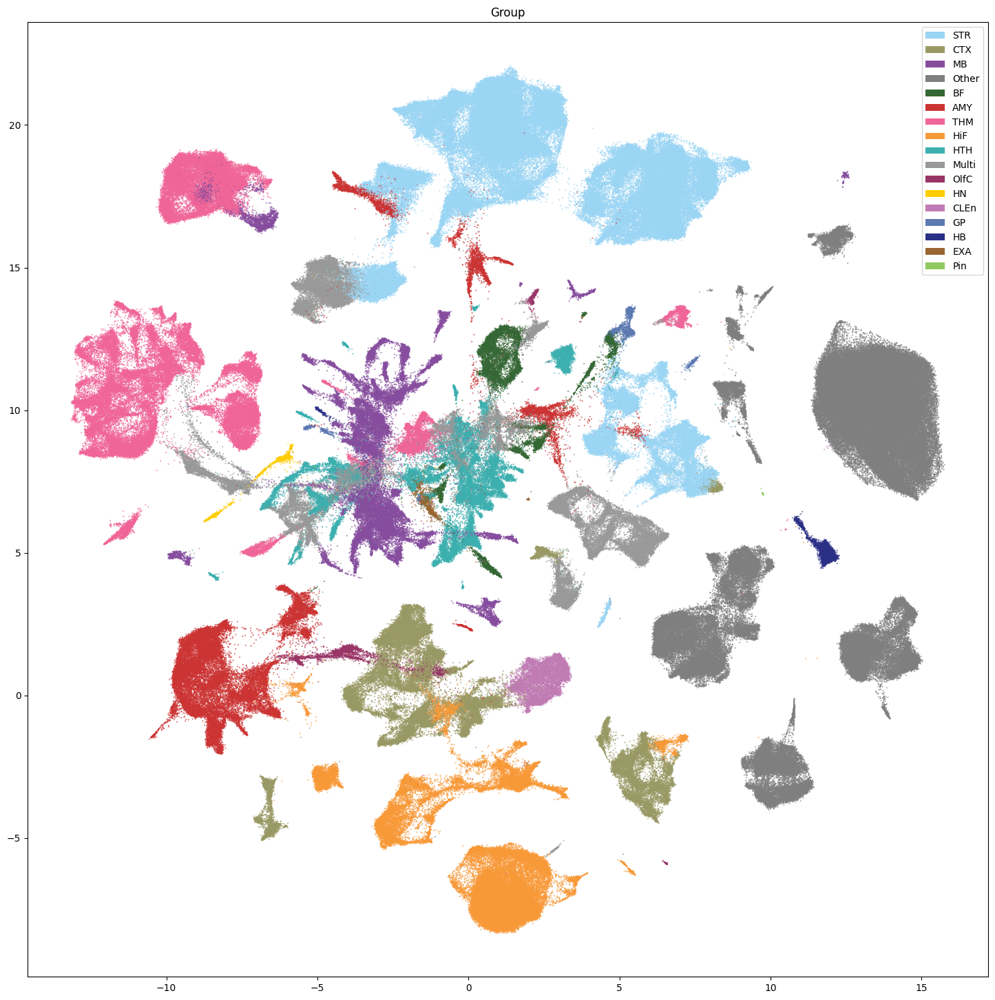

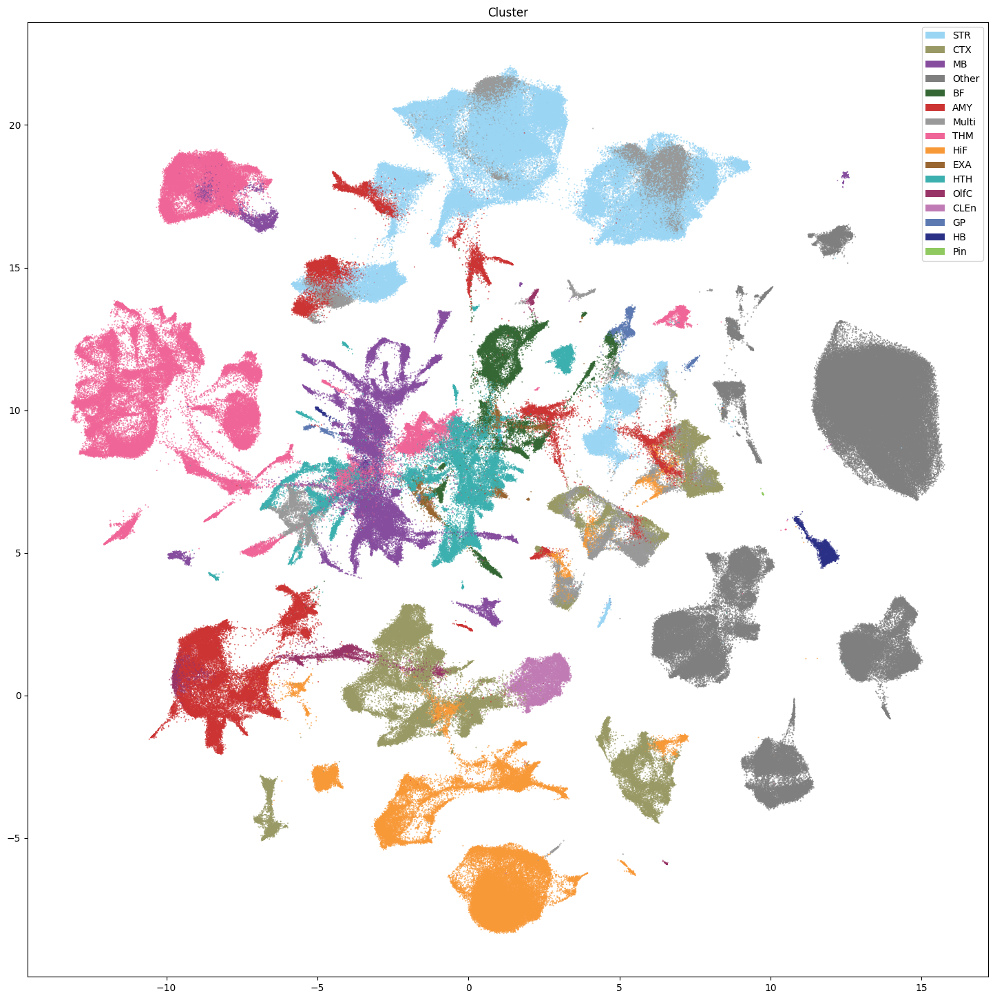

In [58]:
for celltype in ['Group', 'Cluster']:
    fig, ax = plot_umap(
        cell_extended['x'],
        cell_extended['y'],
        cc=cell_extended[f'{celltype}_Dominant_Region_color'],
        labels=cell_extended[f'{celltype}_Dominant_Region'],
        fig_width=18,
        fig_height=18
    )
    res = ax.set_title(celltype)
    plt.show()

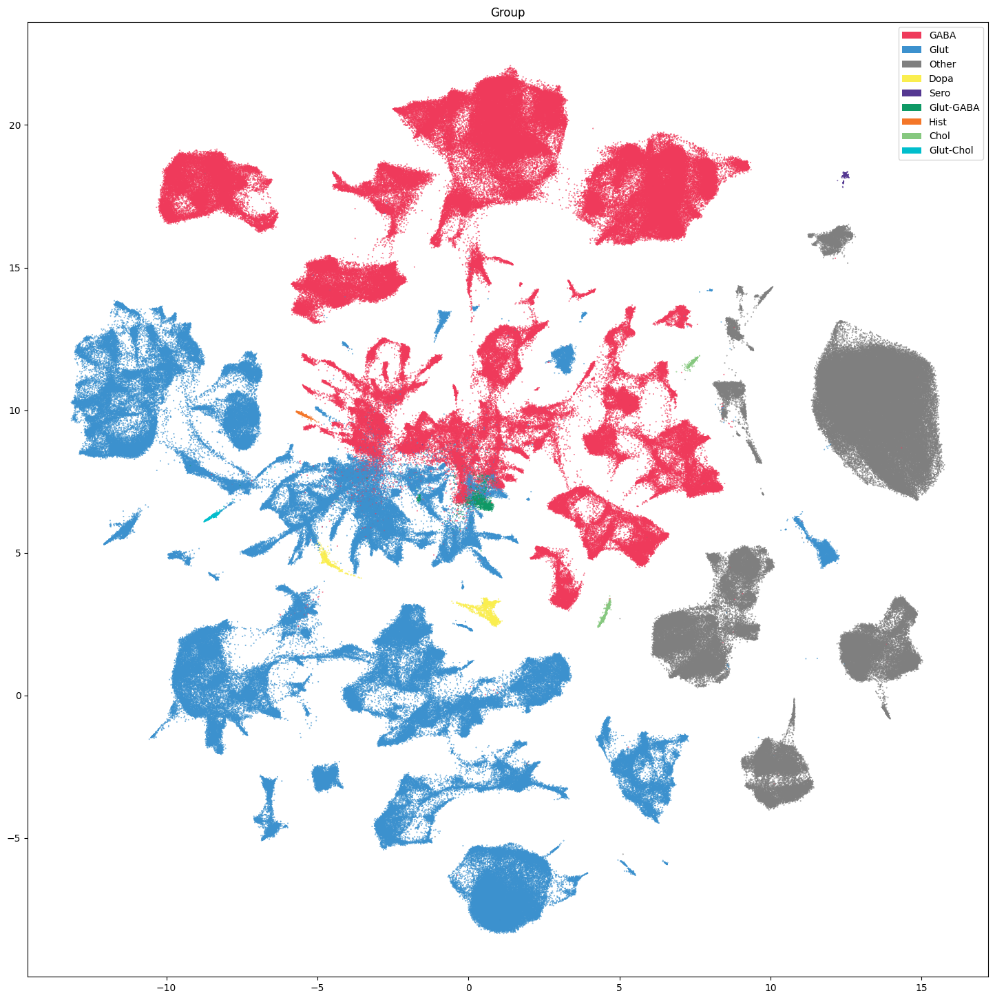

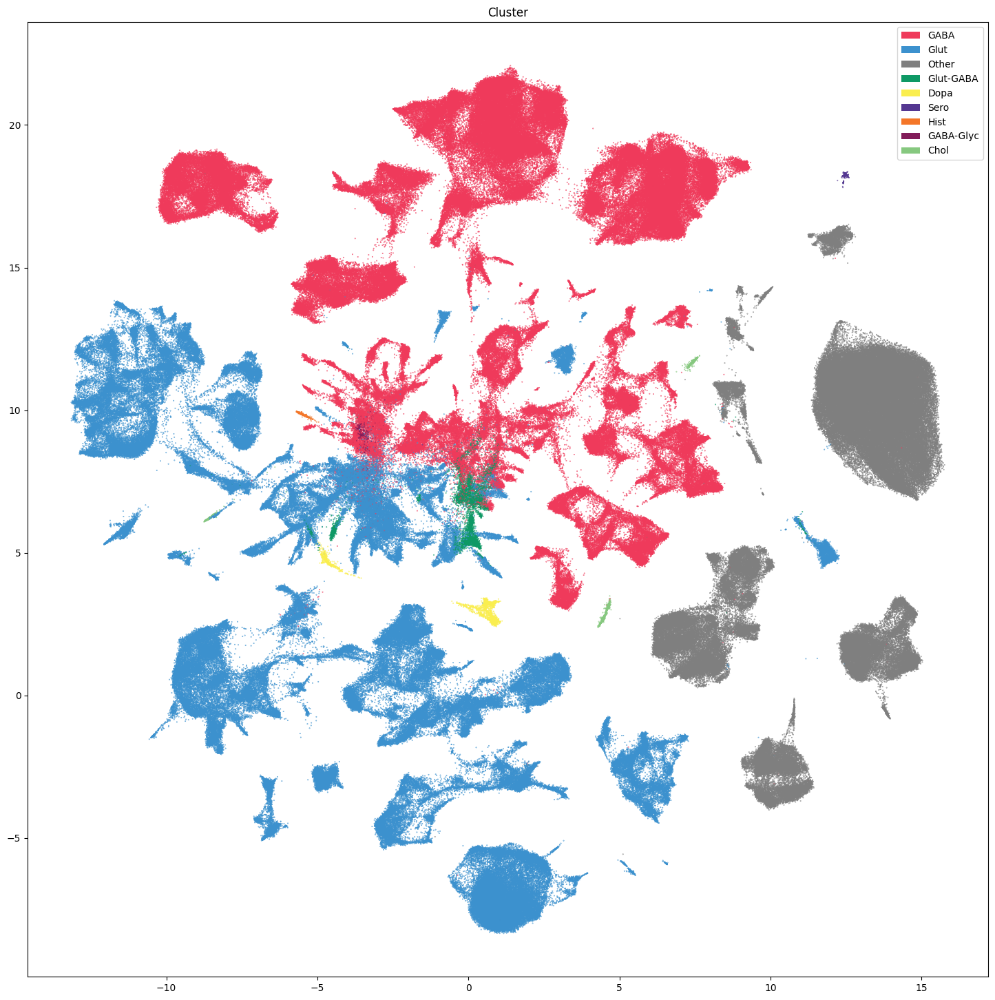

In [59]:
for celltype in ['Group', 'Cluster']:
    fig, ax = plot_umap(
        cell_extended['x'],
        cell_extended['y'],
        cc=cell_extended[f'{celltype}_NT_color'],
        labels=cell_extended[f'{celltype}_NT'],
        fig_width=18,
        fig_height=18
    )
    res = ax.set_title(celltype)
    plt.show()

### Aggregating Cluster and cells counts.

Let's investigate the taxonomy information a bit more. In this section, we'll create bar plots showing the number of Cluster and cells at each level in the taxonomy.

First, we need to compute the number of Cluster that are in each of the cell type taxons above it. This is accomplished by a simple groupby in Pandas.

In [44]:
term_cluster_count = membership_with_cluster_info.reset_index().groupby(
        ['cluster_annotation_term_label']
    )[['cluster_alias']].count()
term_cluster_count.columns = ['number_of_clusters']
term_cluster_count.head()

,number_of_clusters
cluster_annotation_term_label,
CS20260831_LVL0_00,403
CS20260831_LVL0_01,130
CS20260831_LVL0_02,58
CS20260831_LVL0_03,14
CS20260831_LVL0_04,5


In [45]:
term_cell_count = membership_with_cluster_info.reset_index().groupby(
    ['cluster_annotation_term_label']
)[['number_of_cells']].sum()
term_cell_count.head()

,number_of_cells
cluster_annotation_term_label,
CS20260831_LVL0_00,197252
CS20260831_LVL0_01,23004
CS20260831_LVL0_02,10719
CS20260831_LVL0_03,2267
CS20260831_LVL0_04,2233


In [46]:
# Join counts with the term dataframe
term_with_counts = cluster_annotation_term.join(term_cluster_count)
term_with_counts = term_with_counts.join(term_cell_count)
term_with_counts.head()

,name,cluster_annotation_term_set_label,cluster_annotation_term_set_name,color_hex_triplet,term_order,term_order.1,term_set_order,parent_term_label,parent_term_name,parent_term_set_label,external_label,number_of_clusters,number_of_cells
cluster_annotation_term_label,,,,,,,,,,,,,
CS20260831_LVL0_00,BG,CCN20260831_LVL0,Class,#CBC3E3,1,1,0,NaN,NaN,NaN,NaN,403,197252
CS20260831_LVL0_01,CNU-HTH GABA,CCN20260831_LVL0,Class,#E69F00,2,2,0,NaN,NaN,NaN,NaN,130,23004
CS20260831_LVL0_02,CNU-HTH Glut,CCN20260831_LVL0,Class,#56B4E9,3,3,0,NaN,NaN,NaN,NaN,58,10719
CS20260831_LVL0_03,CTX-CGE GABA,CCN20260831_LVL0,Class,#839fa3,4,4,0,NaN,NaN,NaN,NaN,14,2267
CS20260831_LVL0_04,CTX-MGE GABA,CCN20260831_LVL0,Class,#ce4c27,5,5,0,NaN,NaN,NaN,NaN,5,2233


Below we create a function to plot the cluster and cell counts in a bar graph, coloring by the associated taxon level.

In [47]:
def bar_plot_by_level_and_type(df: pd.DataFrame, level: str, fig_width: float = 8.5, fig_height: float = 4):
    """Plot the number of cells by the specified level.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing cluster annotation terms with counts.
    level : str
        The level of the taxonomy to plot (e.g., 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster').
    fig_width : float, optional
        Width of the figure in inches. Default is 8.5.
    fig_height : float, optional
        Height of the figure in inches. Default is 4.
    """

    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(fig_width, fig_height)

    for idx, ctype in enumerate(['clusters', 'cells']):

        pred = (df['cluster_annotation_term_set_name'] == level)
        sort_order = np.argsort(df[pred]['term_order'])
        names = df[pred]['name'].iloc[sort_order]
        counts = df[pred]['number_of_%s' % ctype].iloc[sort_order]
        colors = df[pred]['color_hex_triplet'].iloc[sort_order]
        
        ax[idx].barh(names, counts, color=colors)
        ax[idx].set_title('Number of %s by %s' % (ctype,level))
        ax[idx].set_xlabel('Number of %s' % ctype)
        if ctype == 'cells':
            ax[idx].set_xscale('log')
        
        if idx > 0:
            ax[idx].set_yticklabels([])

    return fig, ax

Now let's plot the counts for each of the taxonomy levels above Cluster.

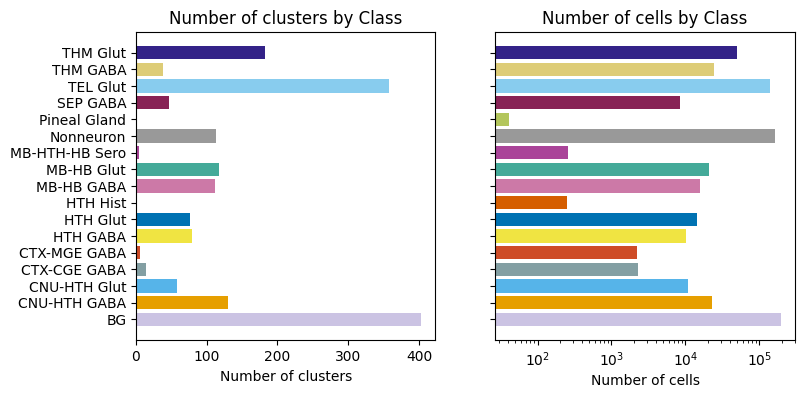

In [48]:
fig, ax = bar_plot_by_level_and_type(term_with_counts, 'Class')
plt.show()

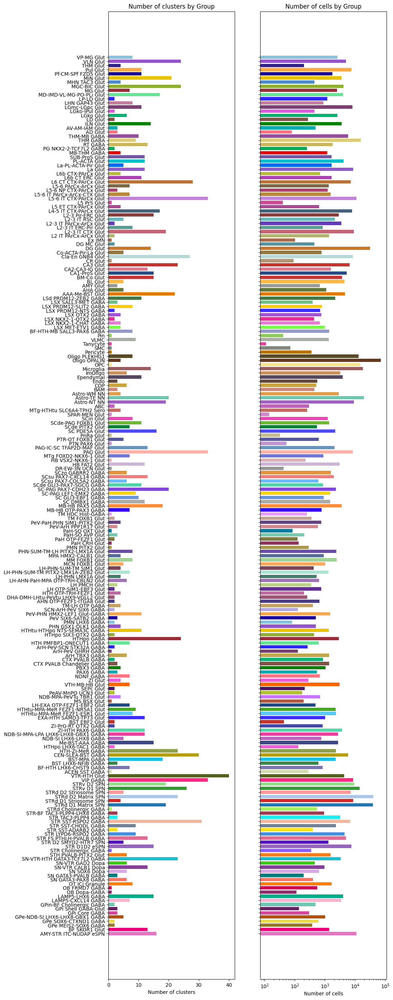

In [52]:
fig, ax = bar_plot_by_level_and_type(term_with_counts, 'Group')
fig.set_size_inches(10, 35)
plt.show()

### Visualizing the Subcortex taxonomy

Term sets: Class, Group, and Cluster define the cross-species taxonomy. We can visualize the taxonomy as a sunburst diagram that shows the single inheritance hierarchy through a series of rings, that are sliced for each annotation term. Each ring corresponds to a level in the hierarchy. We have ordered the rings so that the Neighborhood level. Rings are divided based on their hierarchical relationship to the parent slice. We use the number of cells in each taxon to define the angle of the taxon in the sunburst diagram.

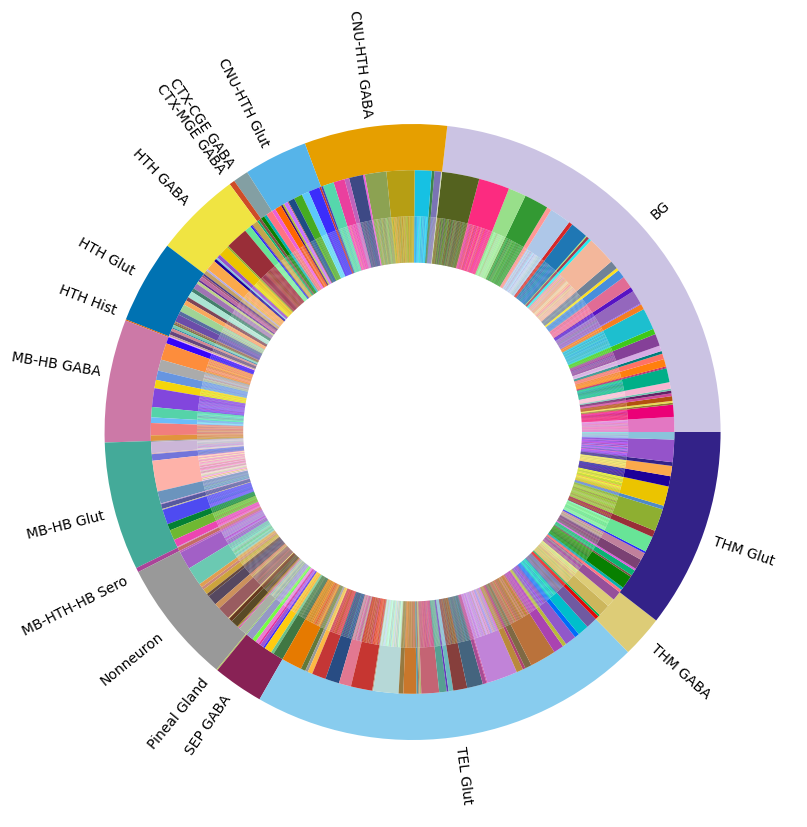

In [50]:
levels = ['Class', 'Group', 'Cluster']
df = {}

# Copy the term order of the parent into each of the level below it.
if term_with_counts.index.name != 'cluster_annotation_term_label':
    term_with_counts = term_with_counts.set_index('cluster_annotation_term_label')
term_with_counts['parent_order'] = ""
for idx, row in term_with_counts.iterrows():
    if pd.isna(row['parent_term_label']):
        continue
    term_with_counts.loc[idx, 'parent_order'] = term_with_counts.loc[row['parent_term_label']]['term_order'].astype(str)

term_with_counts = term_with_counts.reset_index()
for lvl in levels:
    pred = term_with_counts['cluster_annotation_term_set_name'] == lvl
    df[lvl] = term_with_counts[pred]
    df[lvl] = df[lvl].sort_values('term_order')

fig, ax = plt.subplots()
fig.set_size_inches(10, 10)
size = 0.15

for i, lvl in enumerate(levels):
    
    if lvl == 'Class':
        ax.pie(df[lvl]['number_of_clusters'],
               colors=df[lvl]['color_hex_triplet'],
               labels = df[lvl]['name'],
               rotatelabels=True,
               labeldistance=1.025,
               radius=1,
               wedgeprops=dict(width=size, edgecolor=None),
               startangle=0)
    else :
        ax.pie(df[lvl]['number_of_clusters'],
               colors=df[lvl]['color_hex_triplet'],
               radius=1-i*size,
               wedgeprops=dict(width=size, edgecolor=None),
               startangle=0)
term_with_counts = term_with_counts.set_index('cluster_annotation_term_label')
plt.show()

In the next tutorial, we show how to access and use [HMBA-Subcortex gene expression data](https://alleninstitute.github.io/abc_atlas_access/notebooks/hmba_subcortex_10X_snRNASeq_tutorial.html).